# **GARCH and Baseline**

In this notebook, we will create a very simple Naive baseline to see if our fancy models can beat it. The purpose of this is to demonstrate using modelling can improve upon trivial assumptions. Why use GARCH? GARCH is a more traditional finance approach to modelling volatility and we want to see if we can improve upon that using Machine Learning.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

In [31]:
prices10 = pd.read_csv("C:/Users/jungn/OneDrive/Documents/Projects/Market-Volatility-Prediction/data/prices10.csv")

In [32]:
prices10 = prices10.rename(columns={"Price":"Date"})

Since we want to predict future 10 day volatility, a very simple prediction could be: "future 10 day volatility = past 10 day volatility". This is a simple but also reasonable prediction, since we saw earlier in the plots where volatility tends to cluster. In other words, periods of high volatility is followed by high volatility, and periods of low volatility is followed by low volatility.

In [33]:
prices10["future_vol_5"] = (prices10["log_return"].rolling(5).std().shift(-5))
prices10["future_vol_20"] = (prices10["log_return"].rolling(20).std().shift(-20))

In [34]:
naive_train = prices10[(prices10["Date"] >= "2015-01-01") & (prices10["Date"] <= "2023-12-31")]
naive_val = prices10[(prices10["Date"] >= "2024-01-01") & (prices10["Date"]<="2025-12-31")]

In [35]:
y_train = naive_train["future_vol_10"]
y_val = naive_val["future_vol_10"]

In [36]:
y_pred_naive = naive_val["vol_10"]

In [37]:
mae = mean_absolute_error(y_val, y_pred_naive)
rmse = root_mean_squared_error(y_val, y_pred_naive)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

MAE: 0.003916
RMSE: 0.006817


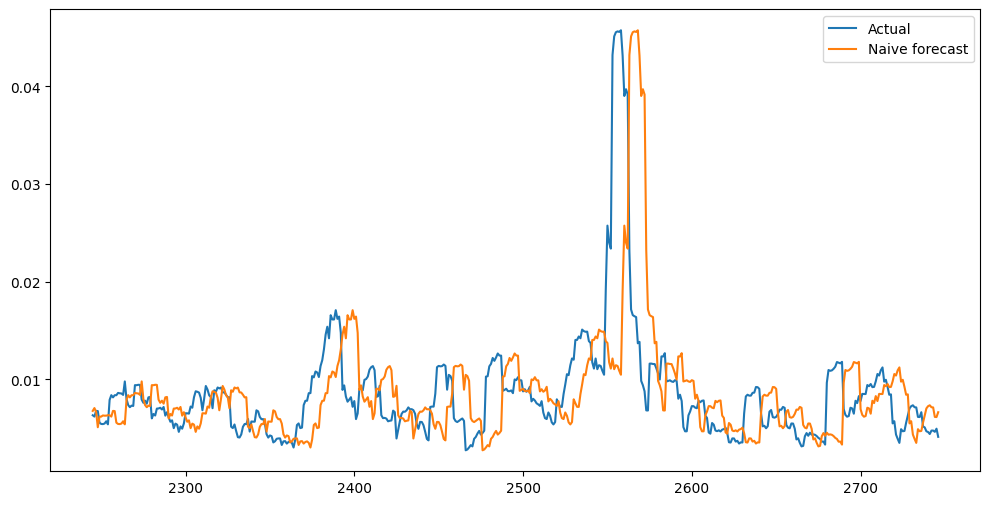

In [38]:
plt.figure(figsize=(12,6))
plt.plot(naive_val.index, y_val, label = "Actual")
plt.plot(naive_val.index, y_pred_naive, label = "Naive forecast")
plt.legend()
plt.show()

In [39]:
fvols = ["future_vol_5","future_vol_20"]
vols = ["vol_5", "vol_20"]

In [40]:
for future_col, vol_col in zip(fvols, vols):
    eval_df = naive_val[
        [future_col, vol_col]
    ].dropna()

    y_val = eval_df[future_col]
    y_pred_naive = eval_df[vol_col]

    mae = mean_absolute_error(y_val, y_pred_naive)
    rmse = root_mean_squared_error(y_val, y_pred_naive)

    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")

MAE: 0.004136
RMSE: 0.006982
MAE: 0.003977
RMSE: 0.006492


We see that vol_10 has lower MAE than vol_20, however it has higher RMSE compared to vol_20. This suggests that vol_10 is closer to true future volatility, however makes more large mistakes compared to vol_20 which is less noisy, more stable and less reactive.

Now that we have our baselines, we want to see if we can beat it using fancy models and machine learning methods.

### **GARCH**

What is GARCH?

Generalised AutoRegressive Conditional Heteroskedasicity (GARCH) is a modelling technique in finance used to help predict the volatility of returns on finanial assets (*investopedia*). It helps analyse time series data, and the resulting information is used set prices, pick and choose promising assets as well as optimising portfolios. 

We will use this technique to see if we can improve upon a classical, traditional approach using machine learning.

In [41]:
from arch import arch_model

In [42]:
returns_train = (naive_train["log_return"]).dropna()


In [43]:
returns_train = returns_train*100

In [44]:
garch = arch_model(
    returns_train,
    vol = "GARCH",
    p = 1,
    q = 1
)

garch_fit = garch.fit(disp="off")

In [45]:
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2892.82
Distribution:                  Normal   AIC:                           5793.64
Method:            Maximum Likelihood   BIC:                           5816.51
                                        No. Observations:                 2245
Date:                Sat, Jul 11 2026   Df Residuals:                     2244
Time:                        16:15:08   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0870  1.553e-02      5.600  2.145e-08 [5.652e-0

In [46]:
forecast = garch_fit.forecast(horizon=10)

In [47]:
forecast.variance.tail()

,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10
2244,0.388026,0.416696,0.444665,0.47195,0.498568,0.524536,0.549869,0.574583,0.598692,0.622212


In [48]:
forecast_vol = np.sqrt(
    forecast.variance.iloc[-1]
)

In [49]:
all_returns = prices10["log_return"]*100

In [50]:
val_dates = naive_val["Date"]
val_dates = naive_val.index

In [51]:
garch_preds = []

In [ ]:
for date in val_dates:
    returns_until_date = all_returns.loc[:date].dropna()

    garch = arch_model(
        returns_until_date,
        vol = "GARCH",
        p=1,
        q=1
    )

    garch_fit = garch.fit(disp = "off")

    forecast = garch_fit.forecast(horizon = 10)

    forcast_var = forecast.variance.iloc[-1]
    
    forecast_vol = np.sqrt(forcast_var)
    
    predicted_vol_10 = forecast_vol.mean()
    #address this later, since it's not quite the same as the target (which is the standard deviation and not the mean)
    #For simplicity, 10-step GARCH forecasts were aggregated by averaging forecasted daily volatilities. Future work could investigate alternative aggregation methods more closely aligned with realized 10-day volatility.
    
    garch_preds.append(predicted_vol_10)

In [53]:
garch_preds = pd.Series(
    garch_preds,
    index=val_dates
)

In [54]:
garch_preds = garch_preds / 100

In [55]:
eval_df = pd.DataFrame({
    "actual": naive_val["future_vol_10"],
    "garch": garch_preds
}).dropna()

In [56]:
mae = mean_absolute_error(
    eval_df["actual"],
    eval_df["garch"]
)

rmse = root_mean_squared_error(
    eval_df["actual"],
    eval_df["garch"]
)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

MAE: 0.003600
RMSE: 0.005938


In [59]:
results = pd.DataFrame({
    "Model": ["Naive Vol_10", "GARCH(1,1)"],
    "MAE": [0.003916, 0.003600],
    "RMSE": [0.006817, 0.005938]
})

results

,Model,MAE,RMSE
0,Naive Vol_10,0.003916,0.006817
1,"GARCH(1,1)",0.003600,0.005938


We see that the RMSE and MAE are both lower than the naive baseline which is what we expected and aiming for.

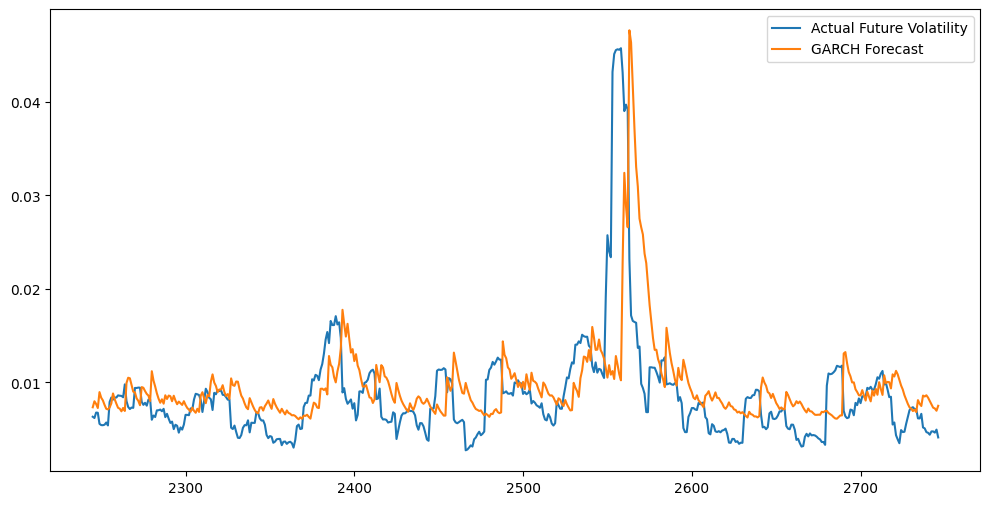

In [60]:
plt.figure(figsize=(12,6))

plt.plot(
    eval_df.index,
    eval_df["actual"],
    label="Actual Future Volatility"
)

plt.plot(
    eval_df.index,
    eval_df["garch"],
    label="GARCH Forecast"
)

plt.legend()
plt.show()

We see that the GARCH model lags a little and consistently overestimates as well especially at the spikes

We now have a naive baseline (past = future), as well as a GARCH baseline (more dynamic/fancy). This means we now have an RMSE to beat, which  is **0.005938**. In the next notebook we will build machine learning models to try and beat that RMSE.